<a href="https://colab.research.google.com/github/algo-akshara/Nvidia-Internship-AIML-Internship-2026/blob/main/NvidiaDay2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install sklearn
!pip install imbalanced-learn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df=pd.read_csv(url)
print(df.head())
print(sns.load_dataset("tips").head())
iris=load_iris(as_frame=True)
print(iris.frame.head())

   survived  pclass     sex   age  ...  deck  embark_town  alive  alone
0         0       3    male  22.0  ...   NaN  Southampton     no  False
1         1       1  female  38.0  ...     C    Cherbourg    yes  False
2         1       3  female  26.0  ...   NaN  Southampton    yes   True
3         1       1  female  35.0  ...     C  Southampton    yes  False
4         0       3    male  35.0  ...   NaN  Southampton     no   True

[5 rows x 15 columns]
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  target
0                5.1               3.5  ...               0.2       0
1                4.9               3.0  ...               0.2       0
2          

In [ ]:
import pandas as pd
import seaborn as sns
df=sns.load_dataset("titanic")
print(df.isnull().sum())
df=df.drop_duplicates()
df['age']=df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
print(df.info())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     784 non-null    int64   
 1   pclass       784 non-null    int64   
 2   sex          784 non-null    object  
 3   age          784 non-null    float64 
 4   sibsp        784 non-null    int64   
 5   parch        784 non-null    int64   
 6   fare         784 non-null    float64 
 7   embarked     784 non-null    object  
 8   class        784 non-null    category
 9   who          784 non-null    object  
 10  adult_male   784 non-null    bool    
 11  deck         202 non-null    category


          survived      pclass   sex         age  ...  deck  embark_town  alive alone
count   891.000000  891.000000   891  714.000000  ...   203          889    891   891
unique         NaN         NaN     2         NaN  ...     7            3      2     2
top            NaN         NaN  male         NaN  ...     C  Southampton     no  True
freq           NaN         NaN   577         NaN  ...    59          644    549   537
mean      0.383838    2.308642   NaN   29.699118  ...   NaN          NaN    NaN   NaN
std       0.486592    0.836071   NaN   14.526497  ...   NaN          NaN    NaN   NaN
min       0.000000    1.000000   NaN    0.420000  ...   NaN          NaN    NaN   NaN
25%       0.000000    2.000000   NaN   20.125000  ...   NaN          NaN    NaN   NaN
50%       0.000000    3.000000   NaN   28.000000  ...   NaN          NaN    NaN   NaN
75%       1.000000    3.000000   NaN   38.000000  ...   NaN          NaN    NaN   NaN
max       1.000000    3.000000   NaN   80.000000  ... 

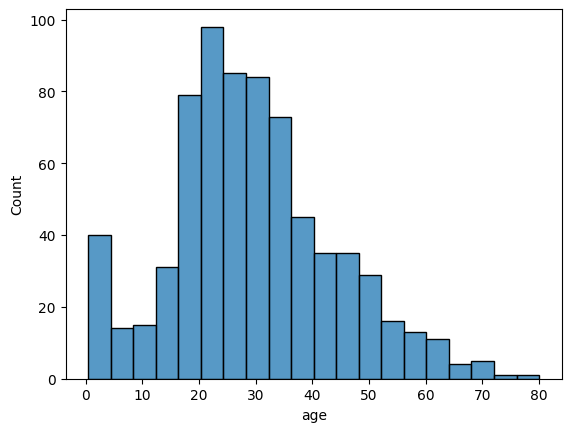

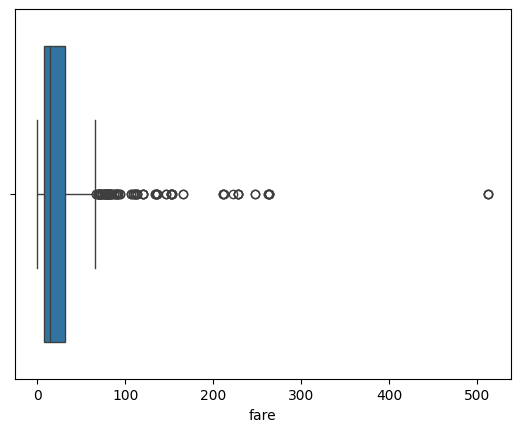

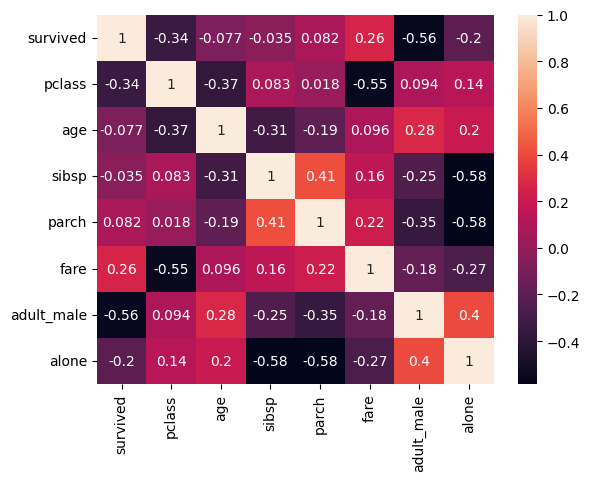

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df=sns.load_dataset("titanic")
print(df.describe(include="all"))
print(df.corr(numeric_only=True))
sns.histplot(df["age"].dropna())
plt.show()
sns.boxplot(x=df["fare"])
plt.show()
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df=pd.DataFrame({"Color":["Red","Blue","Green","Red"]})
le=LabelEncoder()
df["Color_Label"]=le.fit_transform(df["Color"])
print(df)
print(pd.get_dummies(df["Color"],prefix="Color"))

   Color  Color_Label
0    Red            2
1   Blue            0
2  Green            1
3    Red            2
   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True


In [ ]:
import pandas as pd

df=pd.DataFrame({"DOB":["2000-01-01","1998-05-10"],"Salary":[50000,70000]})
df["DOB"]=pd.to_datetime(df["DOB"])
df["Age"]=2026-df["DOB"].dt.year
df["Salary_Log"]=df["Salary"].apply(__import__("math").log)
print(df)

         DOB  Salary  Age  Salary_Log
0 2000-01-01   50000   26   10.819778
1 1998-05-10   70000   28   11.156251


In [ ]:
from sklearn.datasets import make_classification
from collections import Counter
from imblearn.over_sampling import SMOTE
X,y=make_classification(n_samples=500,weights=[0.9,0.1],random_state=42)
print(Counter(y))
Xr,yr=SMOTE(random_state=42).fit_resample(X,y)
print(Counter(yr))

Counter({np.int64(0): 448, np.int64(1): 52})
Counter({np.int64(0): 448, np.int64(1): 448})
